# The Metal Corpus
### A Linguistic Analysis of Heavy Metal Lyrics

*A data science portfolio project by William Anderson*

---

## Setup

In [3]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect('/Users/williamanderson/VisualStudio/metal_lyrics85.db')

subgenres = ['traditional', 'thrash', 'death', 'black', 'groove', 'progressive', 'doom', 'power', 'glam', 'nu', 'other']

df_words = pd.read_sql("SELECT * FROM words", conn)
df_artists = pd.read_sql("SELECT * FROM artists", conn)
df_releases = pd.read_sql("SELECT * FROM releases", conn)
df_songs = pd.read_sql("SELECT * FROM songs", conn)

print(f"Unique words: {len(df_words):,}")
print(f"Artists: {len(df_artists):,}")
print(f"Releases: {len(df_releases):,}")
print(f"Songs: {len(df_songs):,}")

Unique words: 76,486
Artists: 374
Releases: 4,011
Songs: 29,568


## Dataset Overview

### Word Count by Subgenre

Note: raw word counts reflect both the verbosity of a genre *and* how many bands are represented in the dataset. Traditional and thrash metal have the most data simply because more bands exist in those categories. The analyses that follow normalize for this where appropriate.

/var/folders/96/9q7nxkn92d96bhmykw182wkm0000gn/T/ipykernel_7979/2044049856.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=totals_df, x='subgenre', y='total_words', palette='dark:crimson')


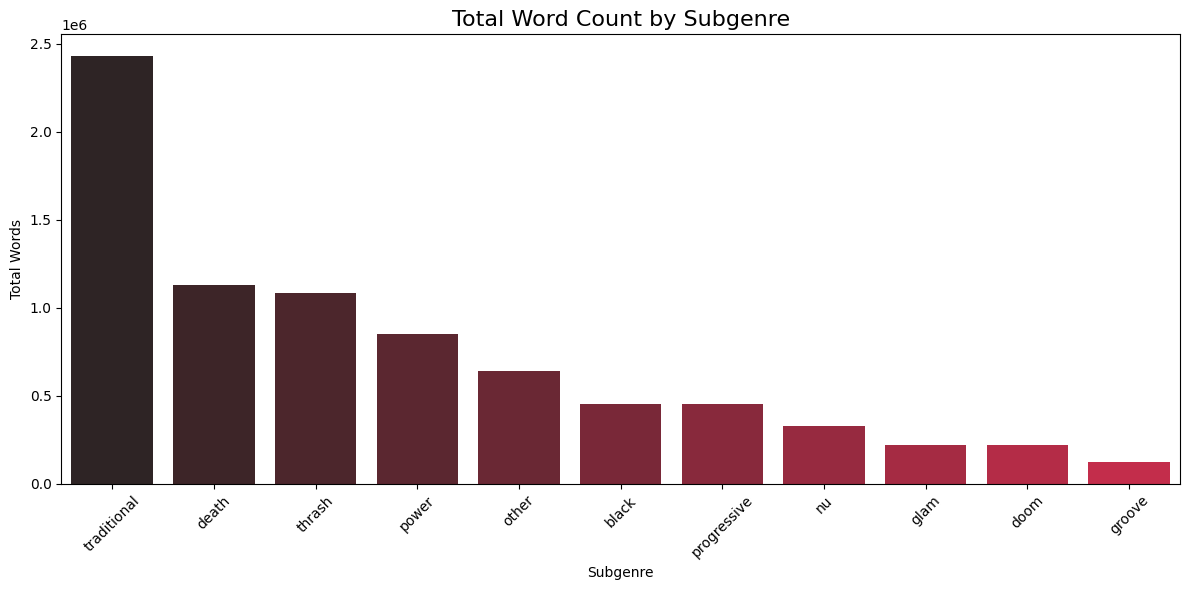

   subgenre  total_words
traditional      2431049
      death      1127492
     thrash      1081673
      power       852532
      other       642438
      black       454915
progressive       451746
         nu       329049
       glam       220664
       doom       220294
     groove       121468


In [4]:
# Word count by subgenre

df_words = pd.read_sql("SELECT * FROM words", conn)

totals = {s: df_words[s].sum() for s in subgenres}
totals_df = pd.DataFrame(list(totals.items()), columns=['subgenre', 'total_words'])
totals_df = totals_df.sort_values('total_words', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=totals_df, x='subgenre', y='total_words', palette='dark:crimson')
plt.title('Total Word Count by Subgenre', fontsize=16)
plt.xlabel('Subgenre')
plt.ylabel('Total Words')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(totals_df.to_string(index=False))

/var/folders/96/9q7nxkn92d96bhmykw182wkm0000gn/T/ipykernel_7979/2237078914.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_artists, x='country', y='band_count', palette='dark:crimson')


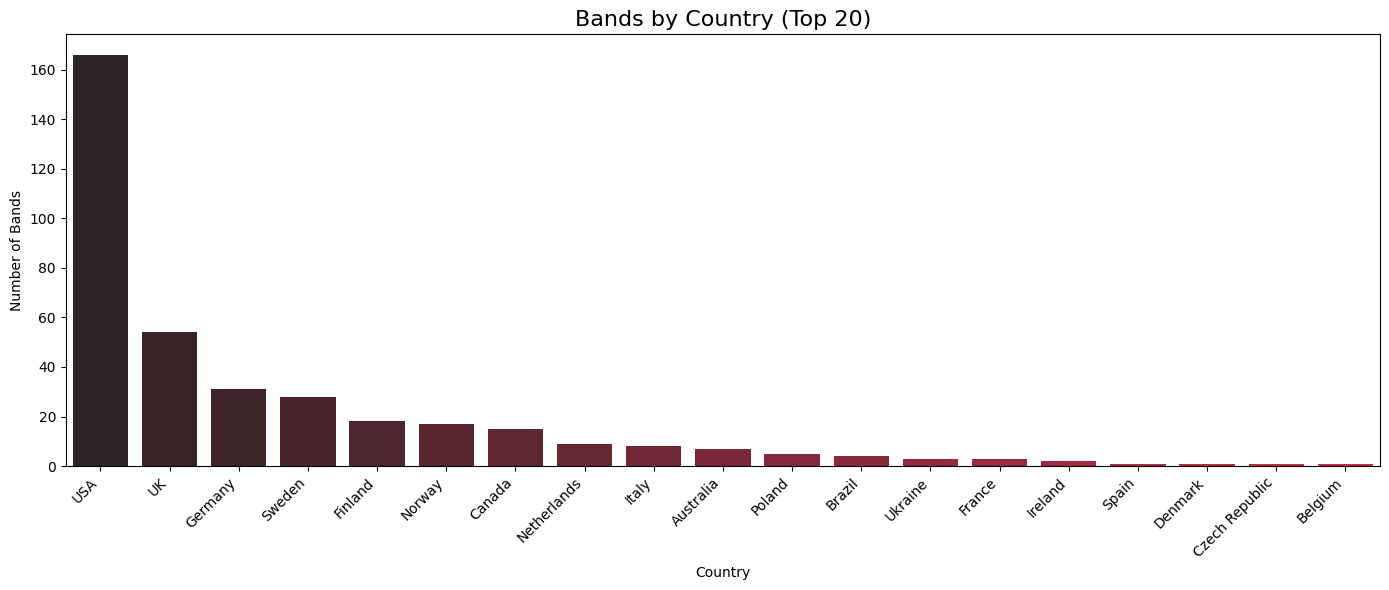

       country  band_count
           USA         166
            UK          54
       Germany          31
        Sweden          28
       Finland          18
        Norway          17
        Canada          15
   Netherlands           9
         Italy           8
     Australia           7
        Poland           5
        Brazil           4
       Ukraine           3
        France           3
       Ireland           2
         Spain           1
       Denmark           1
Czech Republic           1
       Belgium           1


In [5]:
df_artists = pd.read_sql("SELECT country, COUNT(*) as band_count FROM artists GROUP BY country ORDER BY band_count DESC LIMIT 20", conn)

plt.figure(figsize=(14, 6))
sns.barplot(data=df_artists, x='country', y='band_count', palette='dark:crimson')
plt.title('Bands by Country (Top 20)', fontsize=16)
plt.xlabel('Country')
plt.ylabel('Number of Bands')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(df_artists.to_string(index=False))